# DeepEnMap: Ordinal-Aware Multi-Modal Energy Poverty Risk Mapping
### Distance-Penalized Cross-Entropy (DPCE) — Full Experimental Pipeline

This notebook implements the DeepEnMap methodology (Algorithms 1–4) and the
associated experimental design: Baseline Comparison (Exp. 1), Sensitivity
Analysis (Exp. 2), Modality Ablation (Exp. 3), Ordinal Error Distribution
(Exp. 4), Computational Cost, and Grad-CAM explainability.

**Data source:** EuroSAT RGB, via `kagglehub` (`apollo2506/eurosat-dataset`),
used as an ordinal land-use → energy-poverty-risk proxy (see Methodology
§ Ordinal Risk Mapping). Demographic features are generated via the
**synthetic proxy strategy** documented in the Experimental Design
(Section: Demographic Data Source, Strategy 2) — swap in real geolocated
Eurostat data by replacing `build_synthetic_demographics()` if available.

**Reproducibility:** fixed seed set `{42, 123, 2024, 7, 99}`, applied to
NumPy/TensorFlow global state, weight init, data split/shuffling, and dropout.


## 1. Setup & Configuration

In [1]:

# Cell 1.1 — Install dependencies (Colab-safe: quiet, only what's missing)
!pip install -q kagglehub keras-flops scipy pandas scikit-learn matplotlib seaborn


In [2]:

# Cell 1.2 — Imports
import os
import json
import time
import random
import itertools
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

# Cell 1.3 — Reproducibility utility
# Fixed seed set per Experimental Design § Reproducibility Statement.
SEED_SET = [42, 123, 2024, 7, 99]

def set_seed(seed: int) -> None:
    """Seed all sources of randomness: Python, NumPy, TF global state.
    Called once per (seed, configuration) run so that CE/DPCE and every
    lambda/modality variant share identical initialization, split order,
    and dropout masks within a given seed index (paired-comparison design).
    """
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


In [4]:

# Cell 1.4 — Global configuration
@dataclass
class Config:
    img_size: int = 64
    n_channels: int = 3
    n_classes: int = 7            # ordinal risk classes, K in Eq. (1)/(2).
                                   # FIXED: was 10 with a non-consecutive RISK_MAPPING
                                   # (values up to 10) that overflowed tf.one_hot(depth=10)
                                   # for the Industrial class. Now 7 consecutive ranks
                                   # {0..6} matching the remapped RISK_MAPPING (Cell 2.3).
    n_demo_features: int = 4
    batch_size: int = 64
    learning_rate: float = 1e-4
    epochs: int = 10
    early_stopping_patience: int = 3
    val_split: float = 0.2
    lambda_values: tuple = (0.0, 0.5, 1.0, 2.0, 5.0)   # Experiment 2 sweep
    default_lambda: float = 1.0                          # Experiments 1, 3
    seeds: tuple = tuple(SEED_SET)
    alpha: float = 0.05                                   # significance level
    output_dir: str = "/content/deepenmap_results"

CFG = Config()
Path(CFG.output_dir).mkdir(parents=True, exist_ok=True)
CFG


Config(img_size=64, n_channels=3, n_classes=7, n_demo_features=4, batch_size=64, learning_rate=0.0001, epochs=10, early_stopping_patience=3, val_split=0.2, lambda_values=(0.0, 0.5, 1.0, 2.0, 5.0), default_lambda=1.0, seeds=(42, 123, 2024, 7, 99), alpha=0.05, output_dir='/content/deepenmap_results')

## 2. Data: EuroSAT Download, Ordinal Risk Mapping, Synthetic Demographics

In [5]:

# Cell 2.1 — Download EuroSAT via kagglehub
import kagglehub

dataset_path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path to dataset files:", dataset_path)


Using Colab cache for faster access to the 'eurosat-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-dataset


In [6]:

# Cell 2.2 — Inspect directory structure, locate the RGB class folders
# NOTE: apollo2506/eurosat-dataset bundles multiple representations
# (RGB JPG/PNG *and* a 13-band GeoTIFF variant, e.g. "EuroSATallBands").
# Both variants use IDENTICAL class folder names ("AnnualCrop", "Forest",
# ...), so matching on folder names alone is ambiguous — os.walk can return
# the TIFF variant first. We disambiguate by peeking at the actual file
# extensions inside a candidate folder and requiring JPG/PNG content.
def find_rgb_root(base_path: str) -> str:
    """Walk the dataset tree, collect every directory whose immediate
    subfolders are exactly the 10 EuroSAT land-use classes, then return
    the first candidate that actually contains JPG/PNG files (not TIFF)."""
    expected_classes = {
        "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
        "Industrial", "Pasture", "PermanentCrop", "Residential",
        "River", "SeaLake",
    }
    candidates = []
    for root, dirs, _ in os.walk(base_path):
        if expected_classes.issubset(set(dirs)):
            candidates.append(root)

    if not candidates:
        raise FileNotFoundError(
            "Could not locate a directory containing the 10 EuroSAT class "
            "folders under the downloaded dataset path. Inspect "
            f"os.walk('{base_path}') manually and adjust find_rgb_root()."
        )

    diagnostics = []
    for cand in candidates:
        sample_dir = Path(cand) / "AnnualCrop"
        sample_files = list(sample_dir.glob("*"))[:20]
        exts = {f.suffix.lower() for f in sample_files}
        diagnostics.append((cand, exts))
        if exts & {".jpg", ".jpeg", ".png"}:
            return cand

    raise FileNotFoundError(
        "Found folder(s) with the 10 EuroSAT class names, but none contain "
        "JPG/PNG files (likely only the multi-band TIFF variant is present).\n"
        "Candidates inspected (folder -> sample file extensions):\n" +
        "\n".join(f"  {cand} -> {sorted(exts)}" for cand, exts in diagnostics)
    )

RGB_ROOT = find_rgb_root(dataset_path)
print("RGB class root:", RGB_ROOT)
print("Classes found:", sorted(os.listdir(RGB_ROOT)))


RGB class root: /kaggle/input/eurosat-dataset/EuroSAT
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'label_map.json', 'test.csv', 'train.csv', 'validation.csv']


In [7]:

# Cell 2.3 — Ordinal risk mapping (Methodology: Ordinal Risk Mapping table)
# FIXED: previously used non-consecutive values {0,1,2,3,5,8,10} with n_classes=10.
# risk_rank=10 (Industrial) overflowed tf.one_hot(depth=10) -> silent all-zero
# one-hot label -> zero training gradient for Industrial samples, and scored as
# true-class-0 at eval time (np.argmax on an all-zero row returns index 0).
# Remapped to 7 CONSECUTIVE indices {0..6} with n_classes=7 (Cell 1.4), so that
# K-1 in the DPCE weight matrix and MAOE denominator reflects the true number
# of ordinal steps between the lowest and highest real classes.
RISK_MAPPING = {
    "Industrial":              6,
    "Highway":                 5,
    "Residential":             4,
    "PermanentCrop":           3,
    "Pasture":                 2,
    "Forest":                  1,
    "HerbaceousVegetation":    1,
    "AnnualCrop":              1,
    "River":                   0,
    "SeaLake":                 0,
}
found_dirs = {d for d in os.listdir(RGB_ROOT) if (Path(RGB_ROOT) / d).is_dir()}
if set(RISK_MAPPING) != found_dirs:
    missing = set(RISK_MAPPING) - found_dirs
    extra = found_dirs - set(RISK_MAPPING)
    raise AssertionError(
        "Class name mismatch — check folder names.\n"
        f"RGB_ROOT: {RGB_ROOT}\n"
        f"In RISK_MAPPING but not found as a folder: {missing or None}\n"
        f"Found as a folder but not in RISK_MAPPING: {extra or None}\n"
        f"All entries in RGB_ROOT (dirs + files): {sorted(os.listdir(RGB_ROOT))}"
    )

# Build a flat (filepath, land_use_class, risk_rank) index
records = []
n_skipped_empty = 0
for cls, rank in RISK_MAPPING.items():
    cls_dir = Path(RGB_ROOT) / cls
    for fp in cls_dir.glob("*"):
        # NOTE: .tif/.tiff excluded on purpose — tf.image.decode_image()
        # cannot decode TIFF (only JPEG/PNG/GIF/BMP), and RGB_ROOT should
        # already be the RGB-only variant, not the multi-band one.
        if fp.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue
        if fp.stat().st_size == 0:  # guards against truncated/interrupted downloads
            n_skipped_empty += 1
            continue
        records.append({"filepath": str(fp), "land_use_class": cls, "risk_rank": rank})

if n_skipped_empty:
    print(f"Skipped {n_skipped_empty} zero-byte file(s) — likely an interrupted download; "
          f"re-download via kagglehub if this number looks large.")

df = pd.DataFrame(records)
print(f"Total images indexed: {len(df)}")
print("\nPer-class counts:")
print(df["land_use_class"].value_counts())
print("\nPer-rank counts (expect imbalance — see Experimental Design, Rank Imbalance Note):")
print(df["risk_rank"].value_counts().sort_index())


Total images indexed: 27000

Per-class counts:
land_use_class
Forest                  3000
Residential             3000
SeaLake                 3000
HerbaceousVegetation    3000
AnnualCrop              3000
Industrial              2500
Highway                 2500
PermanentCrop           2500
River                   2500
Pasture                 2000
Name: count, dtype: int64

Per-rank counts (expect imbalance — see Experimental Design, Rank Imbalance Note):
risk_rank
0    5500
1    9000
2    2000
3    2500
4    3000
5    2500
6    2500
Name: count, dtype: int64


In [8]:

# Cell 2.4 — Synthetic demographic feature generator
# Per Experimental Design § Demographic Data Source, Strategy 2 (fallback):
# 4 features correlated with risk_rank + injected noise. This is
# SUFFICIENT to validate DPCE's mathematical behavior (loss/label-driven,
# architecture-agnostic to how D is obtained) but must be reported as a
# limitation for any real-world energy-poverty claim (RQ4 caveat).
#
# To switch to real data (Strategy 1): replace this function with a join
# against geolocated Eurostat regional indicators keyed by patch coordinates,
# keeping the same (N, 4) output contract.

DEMO_FEATURE_NAMES = ["income_index", "unemployment_rate", "building_age_index", "population_density"]

def build_synthetic_demographics(risk_ranks: np.ndarray, seed: int, noise_scale: float = 1.5) -> np.ndarray:
    """Generate a (N, 4) synthetic demographic matrix correlated with
    ordinal risk rank, emulating plausible demographic-risk association."""
    rng = np.random.default_rng(seed)
    n = len(risk_ranks)
    r = risk_ranks.astype(float)

    income_index        = -r + rng.normal(0, noise_scale, n)          # higher risk -> lower income
    unemployment_rate   =  r + rng.normal(0, noise_scale, n)          # higher risk -> higher unemployment
    building_age_index  =  r + rng.normal(0, noise_scale, n)          # higher risk -> older buildings
    population_density  = -0.5 * r + rng.normal(0, noise_scale, n)    # mild inverse trend

    return np.stack(
        [income_index, unemployment_rate, building_age_index, population_density],
        axis=1
    ).astype(np.float32)


In [9]:

# Cell 2.5 — Stratified train/validation split (Algorithm 1, Step 4)
# Stratified by risk_rank to preserve the (imbalanced) rank distribution
# across train/val, consistent with Table: Sample Distribution Across Ordinal Risk Ranks.
train_df, val_df = train_test_split(
    df, test_size=CFG.val_split, stratify=df["risk_rank"], random_state=SEED_SET[0]
)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")


Train: 21600  |  Val: 5400


In [10]:

# Cell 2.6 — tf.data pipeline (Algorithm 1: normalize images, standardize
# demographics, one-hot encode labels)
def load_and_preprocess_image(filepath: tf.Tensor, size: int) -> tf.Tensor:
    img_bytes = tf.io.read_file(filepath)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img = tf.image.resize(img, [size, size])
    img = tf.cast(img, tf.float32)
    # Per-image min-max normalization (Algorithm 1, Step 1)
    img_min = tf.reduce_min(img)
    img_max = tf.reduce_max(img)
    img = (img - img_min) / (img_max - img_min + 1e-8)
    return img

def make_dataset(frame: pd.DataFrame, cfg: Config, seed: int, shuffle: bool,
                  demo_mean: np.ndarray = None, demo_std: np.ndarray = None):
    """Builds a tf.data.Dataset yielding ((image, demo), one_hot_label).
    Demographic standardization (Algorithm 1, Step 2) uses train-set
    mean/std passed in for the val set to avoid leakage."""
    filepaths = frame["filepath"].values
    ranks = frame["risk_rank"].values.astype(np.int32)
    demo_raw = build_synthetic_demographics(ranks, seed=seed)

    if demo_mean is None:  # fit on this split (should only be called on train)
        demo_mean = demo_raw.mean(axis=0)
        demo_std = demo_raw.std(axis=0) + 1e-8
    demo_std_feats = (demo_raw - demo_mean) / demo_std

    labels_onehot = tf.one_hot(ranks, depth=cfg.n_classes).numpy()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, demo_std_feats, labels_onehot))

    def _map_fn(fp, demo, label):
        img = load_and_preprocess_image(fp, cfg.img_size)
        return (img, demo), label

    ds = ds.map(_map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(frame), 4096), seed=seed)
    ds = ds.batch(cfg.batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, demo_mean, demo_std


Image batch shape: (64, 64, 64, 3)
Demo batch shape: (64, 4)
Label batch shape: (64, 7)


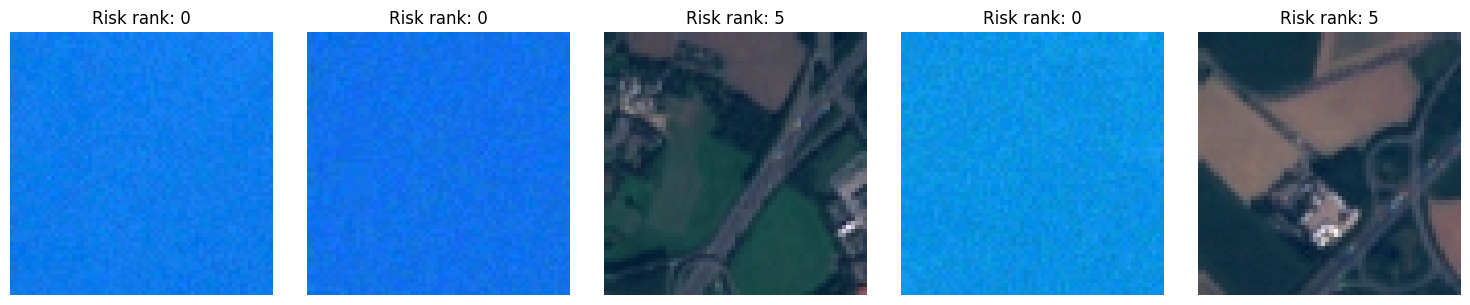

In [11]:

# Cell 2.7 — Sanity check: build one dataset instance and visualize samples
set_seed(SEED_SET[0])
train_ds_preview, demo_mean_preview, demo_std_preview = make_dataset(
    train_df, CFG, seed=SEED_SET[0], shuffle=True
)
val_ds_preview, _, _ = make_dataset(
    val_df, CFG, seed=SEED_SET[0], shuffle=False,
    demo_mean=demo_mean_preview, demo_std=demo_std_preview
)

for (imgs, demos), labels in train_ds_preview.take(1):
    print("Image batch shape:", imgs.shape)
    print("Demo batch shape:", demos.shape)
    print("Label batch shape:", labels.shape)

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i].numpy())
        rank = int(tf.argmax(labels[i]).numpy())
        ax.set_title(f"Risk rank: {rank}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 3. Model Architecture (Algorithms 2 & 3)

In [12]:

# Cell 3.1 — CNN branch (Algorithm 2: Spatial Feature Extraction)
def build_cnn_branch(cfg: Config) -> keras.Model:
    inputs = layers.Input(shape=(cfg.img_size, cfg.img_size, cfg.n_channels), name="image_input")

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2, strides=2)(x)          # -> 32x32x32

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2, strides=2)(x)          # -> 16x16x64

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D(2, strides=2)(x)          # -> 8x8x128

    x = layers.Flatten()(x)                        # -> 8192
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    return keras.Model(inputs=inputs, outputs=x, name="cnn_branch")


In [13]:

# Cell 3.2 — Demographic branch
def build_demo_branch(cfg: Config) -> keras.Model:
    inputs = layers.Input(shape=(cfg.n_demo_features,), name="demo_input")
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    return keras.Model(inputs=inputs, outputs=x, name="demo_branch")


In [14]:

# Cell 3.3 — Fusion + classifier (Algorithm 3), parameterized by modality
# so the SAME builder serves Experiment 1/2 (multi-modal) and
# Experiment 3 (image-only / demo-only ablation).
def build_model(cfg: Config, modality: str = "multi") -> keras.Model:
    assert modality in {"multi", "image", "demo"}

    image_input = layers.Input(shape=(cfg.img_size, cfg.img_size, cfg.n_channels), name="image_input")
    demo_input = layers.Input(shape=(cfg.n_demo_features,), name="demo_input")

    if modality in ("multi", "image"):
        cnn = build_cnn_branch(cfg)
        z_s = cnn(image_input)
    if modality in ("multi", "demo"):
        demo_net = build_demo_branch(cfg)
        z_d = demo_net(demo_input)

    if modality == "multi":
        z_fused = layers.Concatenate(axis=1, name="fusion_concat")([z_s, z_d])   # B x 320
        model_inputs = [image_input, demo_input]
    elif modality == "image":
        z_fused = z_s
        model_inputs = image_input          # demo_input stays unused/unconnected on purpose
    else:  # demo
        z_fused = z_d
        model_inputs = demo_input           # image_input stays unused/unconnected on purpose

    logits = layers.Dense(cfg.n_classes, name="logits")(z_fused)
    probs = layers.Softmax(name="softmax_output")(logits)

    # NOTE: only the inputs actually wired into the output graph may be
    # listed here — Keras's Functional API raises "`inputs` not connected
    # to `outputs`" if you declare an Input that nothing downstream uses.
    model = keras.Model(inputs=model_inputs, outputs=probs, name=f"deepenmap_{modality}")
    return model


In [15]:

# Cell 3.4 — Instantiate and inspect the multi-modal model
demo_model = build_model(CFG, modality="multi")
demo_model.summary()

total_params = demo_model.count_params()
print(f"\\nTotal parameters: {total_params:,}")


Model: "deepenmap_multi"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demo_input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch          │ (None, 256)       │  2,191,552 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ demo_branch         │ (None, 64)        │      8,896 │ demo_input[0][0]  │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 320)       │          0 │ cnn_branch[0][0], │
│ (Concatenate)       │                   │            │ demo_branch[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 7)         │      2,247 │ fusion_concat[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_output      │ (None, 7)         │          0 │ logits[0][0]      │
│ (Softmax)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,202,695 (8.40 MB)

 Trainable params: 2,202,247 (8.40 MB)

 Non-trainable params: 448 (1.75 KB)

\nTotal parameters: 2,202,695


## 4. Loss Functions: Standard CE and Distance-Penalized Cross-Entropy (DPCE)

In [16]:

# Cell 4.1 — DPCE loss (Methodology, Equation 1 — CORRECTED)
# BUG (found by re-deriving the math): the original formula
#   L = -1/B * sum_i sum_c (1 + lambda*|y_i-c|/(K-1)) * L[i,c] * log(Yhat[i,c]+eps)
# multiplies by the one-hot label L[i,c], which is nonzero only at c=y_i. At that
# single surviving term, |y_i - c| = |y_i - y_i| = 0, so the weight collapses to
# exactly 1 for EVERY value of lambda. The distance-penalty mechanism never
# activates: L_DPCE was identically equal to standard CE for all lambda, not just
# lambda=0. (This is visible in the original Cell 4.2 output: DPCE(lambda=1) printed
# the same value as standard CE, contradicting its own "should be >= CE" comment.)
#
# FIXED formula: add an explicit ordinal penalty term that acts on the FULL
# predicted distribution (not masked by the one-hot label), penalizing probability
# mass the model places on ordinally distant wrong classes:
#
#   L_DPCE = 1/B * sum_i [ -log(Yhat[i, y_i] + eps)
#                          + lambda * sum_c ( |y_i - c| / (K-1) ) * Yhat[i, c] ]
#
# At lambda=0 the second term vanishes and this reduces exactly to standard CE
# (Proposition 1 still holds). At lambda>0, Yhat[i,c] for c != y_i is generally
# nonzero, so the penalty is now genuinely active and differentiable.
class DistancePenalizedCrossEntropy(keras.losses.Loss):
    """L_DPCE = 1/B * sum_i [ -log(Yhat[i,y_i]+eps) + lambda * sum_c dist(y_i,c) * Yhat[i,c] ]

    At lambda=0 this reduces exactly to standard categorical cross-entropy
    (Proposition 1). The distance matrix dist[y,c] = |y-c|/(K-1) is precomputed
    as a (K, K) matrix for efficiency.
    """

    def __init__(self, num_classes: int, lam: float = 1.0, eps: float = 1e-8, name="dpce_loss"):
        super().__init__(name=name)
        self.num_classes = num_classes
        self.lam = lam
        self.eps = eps

        ranks = tf.range(num_classes, dtype=tf.float32)
        dist = tf.abs(ranks[:, None] - ranks[None, :]) / tf.cast(num_classes - 1, tf.float32)
        self.dist_matrix = dist   # shape (K, K), row = true class y, col = candidate c

    def call(self, y_true, y_pred):
        # y_true: (B, K) one-hot ; y_pred: (B, K) softmax probabilities
        true_class = tf.argmax(y_true, axis=1)                          # (B,)

        # Standard NLL term: -log(Yhat[i, y_i] + eps)
        log_probs = tf.math.log(y_pred + self.eps)
        nll = -tf.reduce_sum(y_true * log_probs, axis=1)                # (B,)

        # Ordinal penalty term: lambda * sum_c dist(y_i, c) * Yhat[i, c]
        dist_per_sample = tf.gather(self.dist_matrix, true_class)       # (B, K)
        penalty = self.lam * tf.reduce_sum(dist_per_sample * y_pred, axis=1)  # (B,)

        per_sample_loss = nll + penalty
        return tf.reduce_mean(per_sample_loss)


def make_loss(num_classes: int, lam: float) -> keras.losses.Loss:
    """lam == 0.0 dispatches to the plain Keras CE for a clean baseline
    reference implementation, independent of the DPCE code path."""
    if lam == 0.0:
        return keras.losses.CategoricalCrossentropy(name="standard_ce")
    return DistancePenalizedCrossEntropy(num_classes=num_classes, lam=lam)


In [17]:

# Cell 4.2 — Unit test: DPCE(lambda=0) must match standard CE (Proposition 1),
# AND DPCE(lambda>0) must now be STRICTLY GREATER than CE when predictions are
# wrong (verifying the ordinal penalty is actually active — this is the check
# that silently failed under the old, degenerate formula).
_y_true = tf.constant([[0, 0, 1, 0, 0, 0, 0]], dtype=tf.float32)   # K=7, true class = 2
_y_pred = tf.constant([[0.05, 0.05, 0.1, 0.2, 0.2, 0.2, 0.2]], dtype=tf.float32)
_y_pred = _y_pred / tf.reduce_sum(_y_pred)

ce = keras.losses.CategoricalCrossentropy()(_y_true, _y_pred).numpy()
dpce0 = DistancePenalizedCrossEntropy(num_classes=7, lam=0.0)(_y_true, _y_pred).numpy()
dpce1 = DistancePenalizedCrossEntropy(num_classes=7, lam=1.0)(_y_true, _y_pred).numpy()

print(f"Standard CE:      {ce:.6f}")
print(f"DPCE (lambda=0):  {dpce0:.6f}  (should equal standard CE)")
print(f"DPCE (lambda=1):  {dpce1:.6f}  (should be > CE, since y_pred puts mass on distant classes)")

assert np.isclose(ce, dpce0, atol=1e-5), "Proposition 1 violated: DPCE(lambda=0) != standard CE"
assert dpce1 > ce + 1e-6, (
    "Ordinal penalty is not active: DPCE(lambda=1) should exceed standard CE "
    "whenever the model places probability mass on ordinally distant classes."
)
print("\nProposition 1 verified: DPCE reduces to standard CE at lambda=0.")
print("Ordinal penalty verified: DPCE(lambda=1) > CE when predictions spread mass onto distant classes.")


Standard CE:      2.302585
DPCE (lambda=0):  2.302585  (should equal standard CE)
DPCE (lambda=1):  2.660918  (should be > CE, since y_pred puts mass on distant classes)

Proposition 1 verified: DPCE reduces to standard CE at lambda=0.
Ordinal penalty verified: DPCE(lambda=1) > CE when predictions spread mass onto distant classes.


## 5. Training & Evaluation Utilities (Algorithm 4, MAOE, Cohen's d)

In [18]:

# Cell 5.1 — Training loop (Algorithm 4: Adam, early stopping on val loss)
def train_model(model: keras.Model, loss_fn, train_ds, val_ds, cfg: Config, verbose: int = 0):
    optimizer = keras.optimizers.Adam(learning_rate=cfg.learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=cfg.early_stopping_patience,
        restore_best_weights=True, verbose=verbose
    )

    start = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=cfg.epochs,
        callbacks=[early_stop], verbose=verbose
    )
    elapsed_min = (time.time() - start) / 60.0
    return model, history, elapsed_min


In [19]:

# Cell 5.2 — Evaluation: accuracy, MAOE (Eq. 2), macro P/R/F1, confusion matrix
def evaluate_model(model: keras.Model, dataset) -> dict:
    # Generic over modality: `dataset` may yield ((image, demo), label) for
    # multi-modal models, or (single_tensor, label) for image-only/demo-only
    # models (see Cell 5.4's modality-aware reshaping). model.predict(x, ...)
    # accepts either a single tensor or a tuple/list of tensors transparently.
    y_true_all, y_pred_all = [], []
    for x, labels in dataset:
        preds = model.predict(x, verbose=0)
        y_true_all.append(np.argmax(labels.numpy(), axis=1))
        y_pred_all.append(np.argmax(preds, axis=1))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    accuracy = float(np.mean(y_true == y_pred))
    maoe = float(np.mean(np.abs(y_true - y_pred)))  # Eq. (2)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(CFG.n_classes)))

    return {
        "accuracy": accuracy, "maoe": maoe,
        "precision_macro": precision, "recall_macro": recall, "f1_macro": f1,
        "confusion_matrix": cm, "y_true": y_true, "y_pred": y_pred,
    }


In [20]:

# Cell 5.3 — Cohen's d (Eq. paired-samples), paired t-test, Holm-Bonferroni
def cohens_d_paired(x: np.ndarray, y: np.ndarray) -> float:
    """Paired Cohen's d = mean(diff) / std(diff). x, y are per-seed
    metric arrays for two conditions (e.g., DPCE vs CE)."""
    diff = np.asarray(x) - np.asarray(y)
    return float(np.mean(diff) / (np.std(diff, ddof=1) + 1e-12))

def paired_comparison(x: np.ndarray, y: np.ndarray) -> dict:
    t_stat, p_val = stats.ttest_rel(x, y)
    d = cohens_d_paired(x, y)
    return {"t_stat": float(t_stat), "p_value": float(p_val), "cohens_d": d}

def holm_bonferroni(p_values: list, alpha: float = 0.05) -> list:
    """Returns per-test reject/accept booleans under Holm-Bonferroni
    family-wise error correction, preserving input order."""
    m = len(p_values)
    order = np.argsort(p_values)
    sorted_p = np.array(p_values)[order]
    reject_sorted = np.zeros(m, dtype=bool)
    for i, p in enumerate(sorted_p):
        threshold = alpha / (m - i)
        if p <= threshold:
            reject_sorted[i] = True
        else:
            break  # Holm's step-down procedure stops at first failure
    reject = np.zeros(m, dtype=bool)
    reject[order] = reject_sorted
    return reject.tolist()


In [21]:

# Cell 5.4 — Generic experiment runner
# Trains `modality` x `lam` across cfg.seeds, returns a tidy results DataFrame
# with per-seed metrics plus aggregated training time / params.
def run_condition(modality: str, lam: float, cfg: Config) -> pd.DataFrame:
    rows = []
    for seed in cfg.seeds:
        set_seed(seed)

        train_ds, demo_mean, demo_std = make_dataset(train_df, cfg, seed=seed, shuffle=True)
        val_ds, _, _ = make_dataset(val_df, cfg, seed=seed, shuffle=False,
                                     demo_mean=demo_mean, demo_std=demo_std)

        # make_dataset() always yields ((image, demo), label). A single-input
        # Keras model (modality="image" or "demo") can't consume a 2-tuple,
        # so reshape the dataset to match what build_model(modality=...)
        # actually declared as its input.
        if modality == "image":
            train_ds = train_ds.map(lambda xy, y: (xy[0], y))
            val_ds = val_ds.map(lambda xy, y: (xy[0], y))
        elif modality == "demo":
            train_ds = train_ds.map(lambda xy, y: (xy[1], y))
            val_ds = val_ds.map(lambda xy, y: (xy[1], y))
        # modality == "multi": leave as ((image, demo), label)

        model = build_model(cfg, modality=modality)
        loss_fn = make_loss(cfg.n_classes, lam)

        model, history, elapsed_min = train_model(model, loss_fn, train_ds, val_ds, cfg, verbose=0)
        metrics = evaluate_model(model, val_ds)

        rows.append({
            "modality": modality, "lambda": lam, "seed": seed,
            "accuracy": metrics["accuracy"], "maoe": metrics["maoe"],
            "precision_macro": metrics["precision_macro"],
            "recall_macro": metrics["recall_macro"], "f1_macro": metrics["f1_macro"],
            "train_time_min": elapsed_min, "n_params": model.count_params(),
            "epochs_run": len(history.history["loss"]),
        })
        print(f"[{modality} | lambda={lam} | seed={seed}] "
              f"acc={metrics['accuracy']:.4f}  MAOE={metrics['maoe']:.4f}  "
              f"time={elapsed_min:.1f}min")

        keras.backend.clear_session()

    return pd.DataFrame(rows)


## 6. Experiment 1 — Baseline Comparison (CE vs. DPCE)  [RQ1, RQ2]

In [22]:

# Cell 6.1 — Run: 5 seeds x {CE (lambda=0), DPCE (lambda=1.0)}, multi-modal
exp1_ce = run_condition(modality="multi", lam=0.0, cfg=CFG)
exp1_dpce = run_condition(modality="multi", lam=CFG.default_lambda, cfg=CFG)

exp1_results = pd.concat([exp1_ce, exp1_dpce], ignore_index=True)
exp1_results.to_csv(f"{CFG.output_dir}/exp1_baseline_comparison.csv", index=False)
exp1_results


[multi | lambda=0.0 | seed=42] acc=0.9146  MAOE=0.1233  time=2.9min
[multi | lambda=0.0 | seed=123] acc=0.9220  MAOE=0.1150  time=2.3min
[multi | lambda=0.0 | seed=2024] acc=0.9196  MAOE=0.1143  time=2.1min
[multi | lambda=0.0 | seed=7] acc=0.9233  MAOE=0.1128  time=2.3min
[multi | lambda=0.0 | seed=99] acc=0.8991  MAOE=0.1489  time=1.6min
[multi | lambda=1.0 | seed=42] acc=0.9144  MAOE=0.1235  time=1.8min
[multi | lambda=1.0 | seed=123] acc=0.9252  MAOE=0.1104  time=2.2min
[multi | lambda=1.0 | seed=2024] acc=0.9194  MAOE=0.1141  time=2.2min
[multi | lambda=1.0 | seed=7] acc=0.9222  MAOE=0.1111  time=2.2min
[multi | lambda=1.0 | seed=99] acc=0.9019  MAOE=0.1415  time=1.6min


,modality,lambda,seed,accuracy,maoe,precision_macro,recall_macro,f1_macro,train_time_min,n_params,epochs_run
0,multi,0.0,42,0.914630,0.123333,0.911556,0.904429,0.906462,2.927391,2202695,10
1,multi,0.0,123,0.922037,0.115000,0.914539,0.919090,0.916522,2.306531,2202695,10
2,multi,0.0,2024,0.919630,0.114259,0.909379,0.921002,0.914778,2.117094,2202695,10
3,multi,0.0,7,0.923333,0.112778,0.915987,0.919834,0.917644,2.282910,2202695,10
4,multi,0.0,99,0.899074,0.148889,0.893923,0.892988,0.892475,1.560675,2202695,7
5,multi,1.0,42,0.914444,0.123519,0.907763,0.904071,0.905649,1.843765,2202695,8
6,multi,1.0,123,0.925185,0.110370,0.920448,0.919010,0.919485,2.195829,2202695,10
7,multi,1.0,2024,0.919444,0.114074,0.912893,0.914481,0.913445,2.181463,2202695,10
8,multi,1.0,7,0.922222,0.111111,0.922789,0.914425,0.918165,2.167613,2202695,10
9,multi,1.0,99,0.901852,0.141481,0.899168,0.891295,0.894223,1.570536,2202695,7


In [23]:

# Cell 6.2 — Aggregate (Table: Baseline Comparison) + significance/effect size
exp1_summary = exp1_results.groupby("lambda")[["accuracy", "maoe"]].agg(["mean", "std"])
print("Results Template: Baseline Comparison\n")
print(exp1_summary)

acc_stats = paired_comparison(exp1_dpce["accuracy"].values, exp1_ce["accuracy"].values)
maoe_stats = paired_comparison(exp1_dpce["maoe"].values, exp1_ce["maoe"].values)

exp1_stats_table = pd.DataFrame([
    {"metric": "accuracy", **acc_stats},
    {"metric": "maoe", **maoe_stats},
])
print("\nResults Template: Significance and Effect Size (DPCE vs. CE)\n")
print(exp1_stats_table)
exp1_stats_table.to_csv(f"{CFG.output_dir}/exp1_significance_effect_size.csv", index=False)


Results Template: Baseline Comparison

        accuracy                maoe          
            mean       std      mean       std
lambda                                        
0.0     0.915741  0.009892  0.122852  0.015126
1.0     0.916630  0.009159  0.120111  0.013044

Results Template: Significance and Effect Size (DPCE vs. CE)

     metric    t_stat   p_value  cohens_d
0  accuracy  1.027105  0.362421  0.459335
1      maoe -1.900562  0.130154 -0.849957


## 7. Experiment 2 — Sensitivity Analysis (λ Sweep)  [RQ3]

In [24]:

# Cell 7.1 — Run: 5 seeds x lambda in CFG.lambda_values, multi-modal
exp2_frames = []
for lam in CFG.lambda_values:
    exp2_frames.append(run_condition(modality="multi", lam=lam, cfg=CFG))
exp2_results = pd.concat(exp2_frames, ignore_index=True)
exp2_results.to_csv(f"{CFG.output_dir}/exp2_sensitivity_sweep.csv", index=False)
exp2_results


[multi | lambda=0.0 | seed=42] acc=0.9220  MAOE=0.1137  time=2.3min
[multi | lambda=0.0 | seed=123] acc=0.9209  MAOE=0.1150  time=2.3min
[multi | lambda=0.0 | seed=2024] acc=0.9148  MAOE=0.1228  time=2.2min
[multi | lambda=0.0 | seed=7] acc=0.9172  MAOE=0.1181  time=2.2min
[multi | lambda=0.0 | seed=99] acc=0.9154  MAOE=0.1248  time=2.3min
[multi | lambda=0.5 | seed=42] acc=0.9159  MAOE=0.1176  time=2.0min
[multi | lambda=0.5 | seed=123] acc=0.9231  MAOE=0.1115  time=2.2min
[multi | lambda=0.5 | seed=2024] acc=0.9209  MAOE=0.1167  time=2.2min
[multi | lambda=0.5 | seed=7] acc=0.9219  MAOE=0.1148  time=2.2min
[multi | lambda=0.5 | seed=99] acc=0.9163  MAOE=0.1198  time=2.2min
[multi | lambda=1.0 | seed=42] acc=0.9115  MAOE=0.1235  time=1.8min
[multi | lambda=1.0 | seed=123] acc=0.9131  MAOE=0.1226  time=2.0min
[multi | lambda=1.0 | seed=2024] acc=0.9176  MAOE=0.1174  time=2.2min
[multi | lambda=1.0 | seed=7] acc=0.9224  MAOE=0.1081  time=2.3min
[multi | lambda=1.0 | seed=99] acc=0.9161 

,modality,lambda,seed,accuracy,maoe,precision_macro,recall_macro,f1_macro,train_time_min,n_params,epochs_run
0,multi,0.0,42,0.922037,0.113704,0.919794,0.913069,0.915842,2.293569,2202695,10
1,multi,0.0,123,0.920926,0.115000,0.914598,0.914579,0.913871,2.292577,2202695,10
2,multi,0.0,2024,0.914815,0.122778,0.904991,0.915810,0.909848,2.164472,2202695,10
3,multi,0.0,7,0.917222,0.118148,0.916187,0.914431,0.915080,2.155657,2202695,10
4,multi,0.0,99,0.915370,0.124815,0.905218,0.917830,0.910540,2.300963,2202695,10
5,multi,0.5,42,0.915926,0.117593,0.909923,0.916899,0.913058,1.960110,2202695,9
6,multi,0.5,123,0.923148,0.111481,0.916149,0.920361,0.918070,2.207460,2202695,10
7,multi,0.5,2024,0.920926,0.116667,0.911447,0.919234,0.915044,2.233700,2202695,10
8,multi,0.5,7,0.921852,0.114815,0.919225,0.917249,0.917844,2.183285,2202695,10
9,multi,0.5,99,0.916296,0.119815,0.914790,0.909967,0.910998,2.233462,2202695,10


In [25]:

# Cell 7.2 — Aggregate + Holm-Bonferroni corrected comparisons vs. lambda=0
exp2_summary = exp2_results.groupby("lambda")[["accuracy", "maoe"]].agg(["mean", "std"])
print("Results Template: Sensitivity Analysis\n")
print(exp2_summary)

baseline_acc = exp2_results.loc[exp2_results["lambda"] == 0.0, "accuracy"].values
baseline_maoe = exp2_results.loc[exp2_results["lambda"] == 0.0, "maoe"].values

nonzero_lambdas = [l for l in CFG.lambda_values if l != 0.0]
p_values_acc, p_values_maoe, d_acc, d_maoe = [], [], [], []
for lam in nonzero_lambdas:
    acc_l = exp2_results.loc[exp2_results["lambda"] == lam, "accuracy"].values
    maoe_l = exp2_results.loc[exp2_results["lambda"] == lam, "maoe"].values
    r_acc = paired_comparison(acc_l, baseline_acc)
    r_maoe = paired_comparison(maoe_l, baseline_maoe)
    p_values_acc.append(r_acc["p_value"]); d_acc.append(r_acc["cohens_d"])
    p_values_maoe.append(r_maoe["p_value"]); d_maoe.append(r_maoe["cohens_d"])

reject_acc = holm_bonferroni(p_values_acc, alpha=CFG.alpha)
reject_maoe = holm_bonferroni(p_values_maoe, alpha=CFG.alpha)

exp2_stats_table = pd.DataFrame({
    "lambda": nonzero_lambdas,
    "p_value_accuracy": p_values_acc, "cohens_d_accuracy": d_acc, "significant_accuracy": reject_acc,
    "p_value_maoe": p_values_maoe, "cohens_d_maoe": d_maoe, "significant_maoe": reject_maoe,
})
print("\nHolm-Bonferroni corrected comparisons vs. lambda=0:\n")
print(exp2_stats_table)
exp2_stats_table.to_csv(f"{CFG.output_dir}/exp2_holm_bonferroni_stats.csv", index=False)


Results Template: Sensitivity Analysis

        accuracy                maoe          
            mean       std      mean       std
lambda                                        
0.0     0.918074  0.003259  0.118889  0.004817
0.5     0.919630  0.003310  0.116074  0.003136
1.0     0.916148  0.004244  0.118815  0.006424
2.0     0.921556  0.005677  0.112370  0.007730
5.0     0.922481  0.004874  0.111852  0.005385

Holm-Bonferroni corrected comparisons vs. lambda=0:

   lambda  p_value_accuracy  cohens_d_accuracy  significant_accuracy  \
0     0.5          0.503640           0.328265                 False   
1     1.0          0.564489          -0.280539                 False   
2     2.0          0.117585           0.889508                 False   
3     5.0          0.028275           1.503141                 False   

   p_value_maoe  cohens_d_maoe  significant_maoe  
0      0.183282      -0.718775             False  
1      0.985376      -0.008721             False  
2      0.066629 

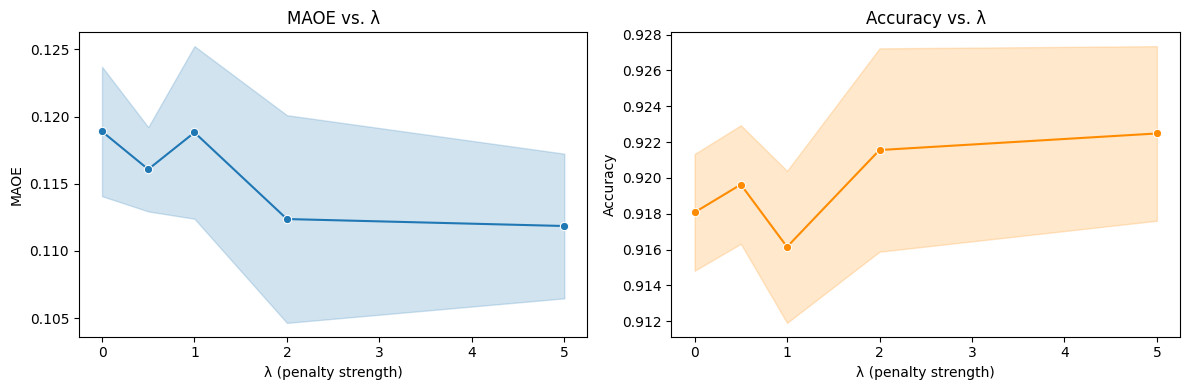

In [26]:

# Cell 7.3 — Plot: MAOE and Accuracy vs. lambda
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=exp2_results, x="lambda", y="maoe", marker="o", ax=axes[0], errorbar="sd")
axes[0].set_title("MAOE vs. λ")
axes[0].set_xlabel("λ (penalty strength)")
axes[0].set_ylabel("MAOE")

sns.lineplot(data=exp2_results, x="lambda", y="accuracy", marker="o", ax=axes[1], errorbar="sd", color="darkorange")
axes[1].set_title("Accuracy vs. λ")
axes[1].set_xlabel("λ (penalty strength)")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/exp2_lambda_sensitivity.png", dpi=150)
plt.show()


## 8. Experiment 3 — Modality Ablation (Image-Only / Demo-Only / Multi-Modal)  [RQ4]

**Caveat:** demographic features are synthetic (Section 2.4). Results here validate the fusion architecture's internal behavior, not a real-world energy-poverty claim (see Experimental Design § Limitations).

In [27]:

# Cell 8.1 — Run: 5 seeds x {image-only, demo-only, multi-modal}, DPCE lambda=1.0
exp3_image = run_condition(modality="image", lam=CFG.default_lambda, cfg=CFG)
exp3_demo = run_condition(modality="demo", lam=CFG.default_lambda, cfg=CFG)
exp3_multi = exp1_dpce.copy()  # reuse Experiment 1's DPCE multi-modal run (same config)
exp3_multi["modality"] = "multi"

exp3_results = pd.concat([exp3_image, exp3_demo, exp3_multi], ignore_index=True)
exp3_results.to_csv(f"{CFG.output_dir}/exp3_modality_ablation.csv", index=False)
exp3_results


[image | lambda=1.0 | seed=42] acc=0.8630  MAOE=0.3202  time=2.1min
[image | lambda=1.0 | seed=123] acc=0.8581  MAOE=0.3257  time=2.2min
[image | lambda=1.0 | seed=2024] acc=0.8543  MAOE=0.3472  time=2.2min
[image | lambda=1.0 | seed=7] acc=0.8600  MAOE=0.3096  time=2.2min
[image | lambda=1.0 | seed=99] acc=0.8611  MAOE=0.3370  time=2.1min
[demo | lambda=1.0 | seed=42] acc=0.5724  MAOE=0.4969  time=1.9min
[demo | lambda=1.0 | seed=123] acc=0.5848  MAOE=0.4787  time=1.8min
[demo | lambda=1.0 | seed=2024] acc=0.5861  MAOE=0.4772  time=1.9min
[demo | lambda=1.0 | seed=7] acc=0.5880  MAOE=0.4774  time=1.8min
[demo | lambda=1.0 | seed=99] acc=0.5822  MAOE=0.4841  time=1.8min


,modality,lambda,seed,accuracy,maoe,precision_macro,recall_macro,f1_macro,train_time_min,n_params,epochs_run
0,image,1.0,42,0.862963,0.320185,0.856587,0.853434,0.852869,2.074606,2193351,10
1,image,1.0,123,0.858148,0.325741,0.852754,0.854725,0.852308,2.246011,2193351,10
2,image,1.0,2024,0.854259,0.347222,0.846185,0.849441,0.846429,2.168938,2193351,10
3,image,1.0,7,0.860000,0.309630,0.861680,0.844066,0.851951,2.246130,2193351,10
4,image,1.0,99,0.861111,0.337037,0.849508,0.849081,0.847974,2.131768,2193351,10
5,demo,1.0,42,0.572407,0.496852,0.456702,0.478043,0.461968,1.861254,9351,10
6,demo,1.0,123,0.584815,0.478704,0.518444,0.499776,0.487967,1.846766,9351,10
7,demo,1.0,2024,0.586111,0.477222,0.470409,0.495141,0.479286,1.867846,9351,10
8,demo,1.0,7,0.587963,0.477407,0.472230,0.497294,0.480286,1.797004,9351,10
9,demo,1.0,99,0.582222,0.484074,0.467788,0.497504,0.480364,1.821346,9351,10


In [28]:

# Cell 8.2 — Aggregate (Table: Ablation Study)
exp3_summary = exp3_results.groupby("modality")[["accuracy", "maoe"]].agg(["mean", "std"])
print("Results Template: Ablation Study\n")
print(exp3_summary)


Results Template: Ablation Study

          accuracy                maoe          
              mean       std      mean       std
modality                                        
demo      0.582704  0.006123  0.482852  0.008307
image     0.859296  0.003314  0.327963  0.014618
multi     0.916630  0.009159  0.120111  0.013044


## 9. Experiment 4 — Ordinal Error Distribution Analysis

In [29]:

# Cell 9.1 — Retrain one CE and one DPCE model at a fixed seed to obtain
# per-sample predictions for the ordinal-distance histogram (Table: Ordinal
# Error Distribution). Uses the first seed in the reproducibility set.
seed = CFG.seeds[0]
set_seed(seed)

train_ds, demo_mean, demo_std = make_dataset(train_df, CFG, seed=seed, shuffle=True)
val_ds, _, _ = make_dataset(val_df, CFG, seed=seed, shuffle=False, demo_mean=demo_mean, demo_std=demo_std)

model_ce = build_model(CFG, modality="multi")
model_ce, history_ce, _ = train_model(model_ce, make_loss(CFG.n_classes, 0.0), train_ds, val_ds, CFG, verbose=0)
metrics_ce = evaluate_model(model_ce, val_ds)
keras.backend.clear_session()

set_seed(seed)
train_ds, demo_mean, demo_std = make_dataset(train_df, CFG, seed=seed, shuffle=True)
val_ds, _, _ = make_dataset(val_df, CFG, seed=seed, shuffle=False, demo_mean=demo_mean, demo_std=demo_std)

model_dpce = build_model(CFG, modality="multi")
model_dpce, history_dpce, _ = train_model(model_dpce, make_loss(CFG.n_classes, CFG.default_lambda), train_ds, val_ds, CFG, verbose=0)
metrics_dpce = evaluate_model(model_dpce, val_ds)


Results Template: Ordinal Error Distribution

  ordinal_distance     CE (%)   DPCE (%)  relative_change (%)
0      0 (Correct)  92.796296  92.574074            -0.239473
1      1-2 (Close)   6.925926   7.018519             1.336898
2   3-4 (Moderate)   0.277778   0.407407            46.666667
3        5-6 (Far)   0.000000   0.000000                  NaN


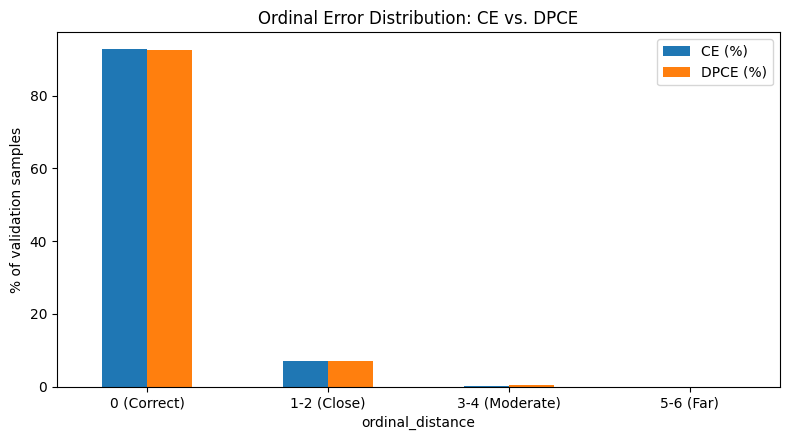

In [30]:

# Cell 9.2 — Bin ordinal distances and build the results table + bar chart
# NOTE: bin edges updated for K=7 (ranks 0..6, max possible |y_true - y_pred| = 6),
# was previously sized for K=10 (bins up to "6-9 (Far)", which no longer exist).
def distance_distribution(y_true, y_pred):
    dist = np.abs(y_true - y_pred)
    bins = {
        "0 (Correct)": np.mean(dist == 0),
        "1-2 (Close)": np.mean((dist >= 1) & (dist <= 2)),
        "3-4 (Moderate)": np.mean((dist >= 3) & (dist <= 4)),
        "5-6 (Far)": np.mean(dist >= 5),
    }
    return bins

dist_ce = distance_distribution(metrics_ce["y_true"], metrics_ce["y_pred"])
dist_dpce = distance_distribution(metrics_dpce["y_true"], metrics_dpce["y_pred"])

exp4_table = pd.DataFrame({
    "ordinal_distance": list(dist_ce.keys()),
    "CE (%)": [v * 100 for v in dist_ce.values()],
    "DPCE (%)": [v * 100 for v in dist_dpce.values()],
})
exp4_table["relative_change (%)"] = (
    (exp4_table["DPCE (%)"] - exp4_table["CE (%)"]) / exp4_table["CE (%)"].replace(0, np.nan) * 100
)
print("Results Template: Ordinal Error Distribution\n")
print(exp4_table)
exp4_table.to_csv(f"{CFG.output_dir}/exp4_ordinal_error_distribution.csv", index=False)

exp4_table.set_index("ordinal_distance")[["CE (%)", "DPCE (%)"]].plot(
    kind="bar", figsize=(8, 4.5), rot=0
)
plt.title("Ordinal Error Distribution: CE vs. DPCE")
plt.ylabel("% of validation samples")
plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/exp4_ordinal_error_distribution.png", dpi=150)
plt.show()


## 10. Computational Cost (Parameters, FLOPs, Training Time)

In [31]:
# Cell 10.1 — Parameter counts and FLOPs per modality
# DPCE changes only the loss, not the architecture, so CE and DPCE variants
# of the same modality are expected to have identical params/FLOPs
# (Experimental Design § Computational Cost).
# NOTE: the third-party `keras_flops` package is unmaintained and crashes
# on recent TensorFlow versions — it tries to register a FLOPs stat for the
# 'AddV2' op that TF's own built-in profiler already registers, raising
# `KeyError: Registering two statistical functions with name 'AddV2,flops'`
# at import time (before any try/except ImportError can catch it). We use
# TensorFlow's official profiler API instead — no extra dependency needed.
def compute_flops(model, batch_size=1):
    """Analytic FLOPs via tf.compat.v1.profiler, run on a concrete function
    traced from the model. Returns None if profiling isn't available in
    this environment, so the rest of the cell still runs off params alone."""
    try:
        inputs = model.inputs if isinstance(model.inputs, list) else [model.inputs]
        specs = [
            tf.TensorSpec(shape=(batch_size,) + tuple(inp.shape[1:]), dtype=inp.dtype)
            for inp in inputs
        ]

        # Keras functional models take exactly ONE positional argument to
        # __call__: a single tensor for single-input models, or a
        # list/tuple of tensors for multi-input models (e.g. model([img,
        # demo])). `specs` must therefore be nested to match whichever of
        # those two calling conventions this particular model uses —
        # passing N separate specs makes tf.function treat them as N
        # separate positional args, which breaks multi-input models.
        arg_signature = specs if len(specs) > 1 else specs[0]

        @tf.function(input_signature=[arg_signature])
        def forward_pass(x):
            return model(x)

        graph_info = tf.compat.v1.profiler.profile(
            forward_pass.get_concrete_function().graph,
            options=tf.compat.v1.profiler.ProfileOptionBuilder.float_operation(),
        )
        return graph_info.total_float_ops
    except Exception as e:
        print(f"  (FLOPs profiling unavailable for this model: {e})")
        return None

cost_rows = []
for modality in ["image", "demo", "multi"]:
    m = build_model(CFG, modality=modality)
    params = m.count_params()
    flops = compute_flops(m, batch_size=1)
    cost_rows.append({"modality": modality, "parameters": params, "flops_per_inference": flops})
    keras.backend.clear_session()

cost_df = pd.DataFrame(cost_rows)

# Merge training time from Experiments 1 & 3
train_time = pd.concat([
    exp1_results.assign(config=lambda d: "multi_" + d["lambda"].apply(lambda l: "CE" if l == 0 else "DPCE")),
    exp3_results.assign(config=lambda d: d["modality"]),
])[["modality", "train_time_min"]].groupby("modality").agg(["mean", "std"])

print("Parameters / FLOPs per modality:\n")
print(cost_df)
print("\nTraining time per modality (minutes):\n")
print(train_time)

cost_df.to_csv(f"{CFG.output_dir}/computational_cost.csv", index=False)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Parameters / FLOPs per modality:

  modality  parameters  flops_per_inference
0    image     2193351             87692394
1     demo        9351                18538
2    multi     2202695             87710890

Training time per modality (minutes):

         train_time_min          
                   mean       std
modality                         
demo           1.838843  0.029423
image          2.173491  0.074289
multi          2.074201  0.356032


## 11. Explainability: Grad-CAM (Methodology, Eq. Grad-CAM/alpha)

In [32]:
# Cell 11.1 — Grad-CAM implementation, computed against the DPCE-trained
# model's loss (per Methodology: "L denotes the DPCE loss").
def make_gradcam_heatmap(img_array, demo_array, model, last_conv_layer_name="last_conv"):
    cnn_submodel = model.get_layer("cnn_branch")
    conv_layer = cnn_submodel.get_layer(last_conv_layer_name)

    # Model confined to the cnn_branch's own graph -> no name clash,
    # since this only traces cnn_submodel's internal input/layers.
    conv_and_cnn_out_model = keras.Model(
        inputs=cnn_submodel.inputs,
        outputs=[conv_layer.output, cnn_submodel.output]
    )

    demo_branch = model.get_layer("demo_branch")
    fusion_concat = model.get_layer("fusion_concat")
    logits_layer = model.get_layer("logits")
    softmax_layer = model.get_layer("softmax_output")

    with tf.GradientTape() as tape:
        conv_outputs, z_s = conv_and_cnn_out_model(img_array)
        tape.watch(conv_outputs)
        z_d = demo_branch(demo_array)
        z_fused = fusion_concat([z_s, z_d])
        logits = logits_layer(z_fused)
        predictions = softmax_layer(logits)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # alpha_k, Eq. (alpha)

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)  # ReLU + normalize, Eq. (gradcam)
    return heatmap.numpy()

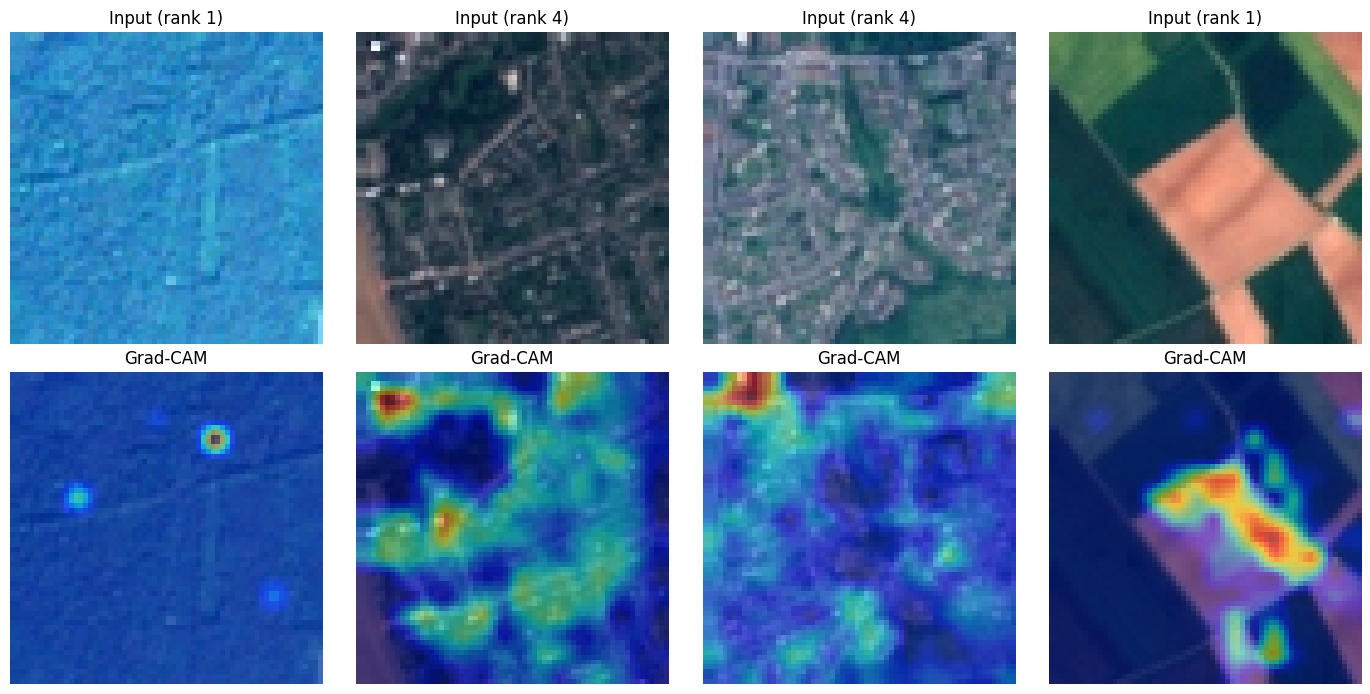

In [33]:

# Cell 11.2 — Visualize Grad-CAM for a few validation samples (DPCE model)
sample_batch = next(iter(val_ds))
(sample_imgs, sample_demos), sample_labels = sample_batch

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    img = sample_imgs[i:i+1]
    demo = sample_demos[i:i+1]
    heatmap = make_gradcam_heatmap(img, demo, model_dpce)
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], [CFG.img_size, CFG.img_size]).numpy().squeeze()

    axes[0, i].imshow(img[0].numpy())
    axes[0, i].set_title(f"Input (rank {int(tf.argmax(sample_labels[i]).numpy())})")
    axes[0, i].axis("off")

    axes[1, i].imshow(img[0].numpy())
    axes[1, i].imshow(heatmap_resized, cmap="jet", alpha=0.5)
    axes[1, i].set_title("Grad-CAM")
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig(f"{CFG.output_dir}/gradcam_samples.png", dpi=150)
plt.show()


## 12. Save Results & Export

In [35]:

# Cell 12.1 — Persist all result tables, configs, and checkpoints
from google.colab import drive
drive.mount('/content/drive')

export_dir = "/content/drive/MyDrive/DeepEnMap_Results"
Path(export_dir).mkdir(parents=True, exist_ok=True)

import shutil
for fname in os.listdir(CFG.output_dir):
    shutil.copy(os.path.join(CFG.output_dir, fname), os.path.join(export_dir, fname))

with open(os.path.join(export_dir, "config.json"), "w") as f:
    json.dump(CFG.__dict__, f, indent=2, default=str)

model_ce.save(os.path.join(export_dir, "model_ce.keras"))
model_dpce.save(os.path.join(export_dir, "model_dpce.keras"))

print(f"All results, configs, and checkpoints saved to: {export_dir}")


Mounted at /content/drive
All results, configs, and checkpoints saved to: /content/drive/MyDrive/DeepEnMap_Results


In [36]:

# Cell 12.2 — Final summary printout
print("=" * 70)
print("DEEPENMAP EXPERIMENTAL PIPELINE — SUMMARY")
print("=" * 70)
print(f"\nExperiment 1 (Baseline): CE acc={exp1_ce['accuracy'].mean():.4f} | "
      f"DPCE acc={exp1_dpce['accuracy'].mean():.4f}")
print(f"                         CE MAOE={exp1_ce['maoe'].mean():.4f} | "
      f"DPCE MAOE={exp1_dpce['maoe'].mean():.4f}")
print(f"\nExperiment 2 (Sensitivity): see exp2_summary / exp2_stats_table above")
print(f"\nExperiment 3 (Ablation): see exp3_summary above")
print(f"\nExperiment 4 (Ordinal Error Distribution): see exp4_table above")
print(f"\nAll artifacts written to: {export_dir}")


DEEPENMAP EXPERIMENTAL PIPELINE — SUMMARY

Experiment 1 (Baseline): CE acc=0.9157 | DPCE acc=0.9166
                         CE MAOE=0.1229 | DPCE MAOE=0.1201

Experiment 2 (Sensitivity): see exp2_summary / exp2_stats_table above

Experiment 3 (Ablation): see exp3_summary above

Experiment 4 (Ordinal Error Distribution): see exp4_table above

All artifacts written to: /content/drive/MyDrive/DeepEnMap_Results


## 13. Portfolio Images (8-Image GitHub Set)
Generates the remaining images needed for the portfolio README. `exp2_lambda_sensitivity.png`, `exp4_ordinal_error_distribution.png`, and `gradcam_samples.png` are already produced by Cells 7.3, 9.2, and 11.2. This cell adds `01`–`06` and `08`, and copies `gradcam_samples.png` to `07_gradcam_heatmaps.png`.

**Run after** Cells 2.3–2.7, 3.4, 9.1/9.2, 11.2, and 12.1 have all executed at least once in this session (it reuses `df`, `val_ds`, `model_dpce`, `metrics_dpce`, `history_ce`/`history_dpce`, and `export_dir`).

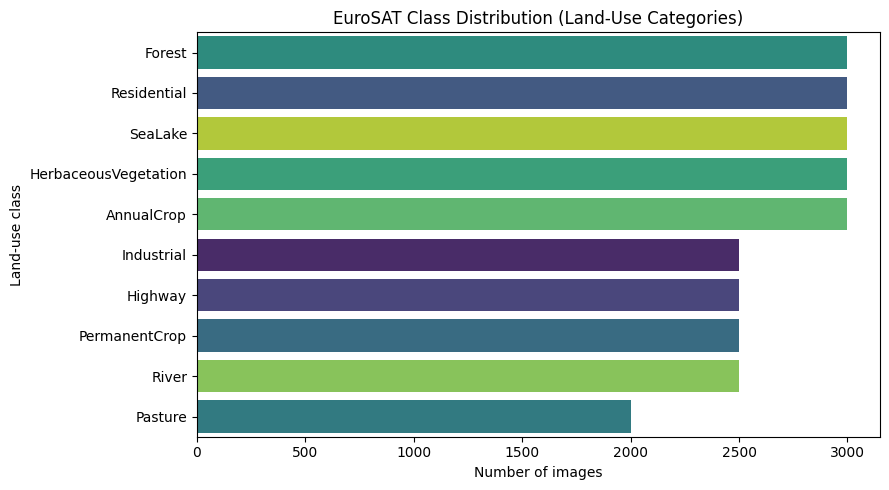

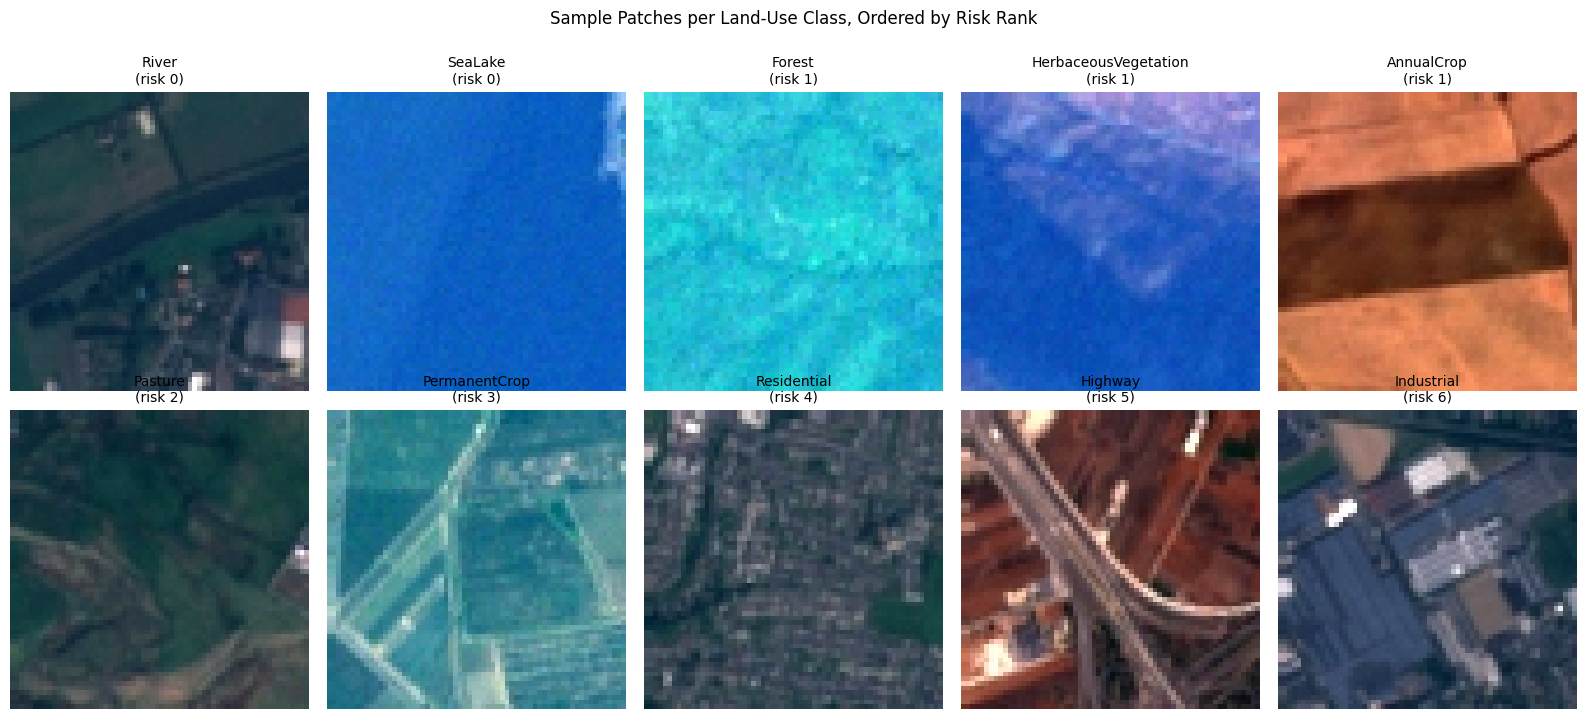

Saved 03_model_architecture.png


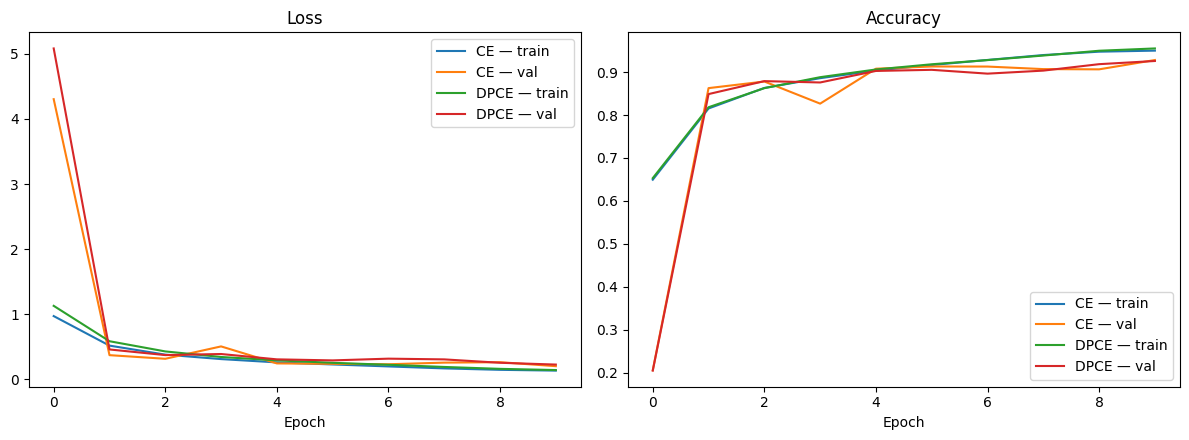

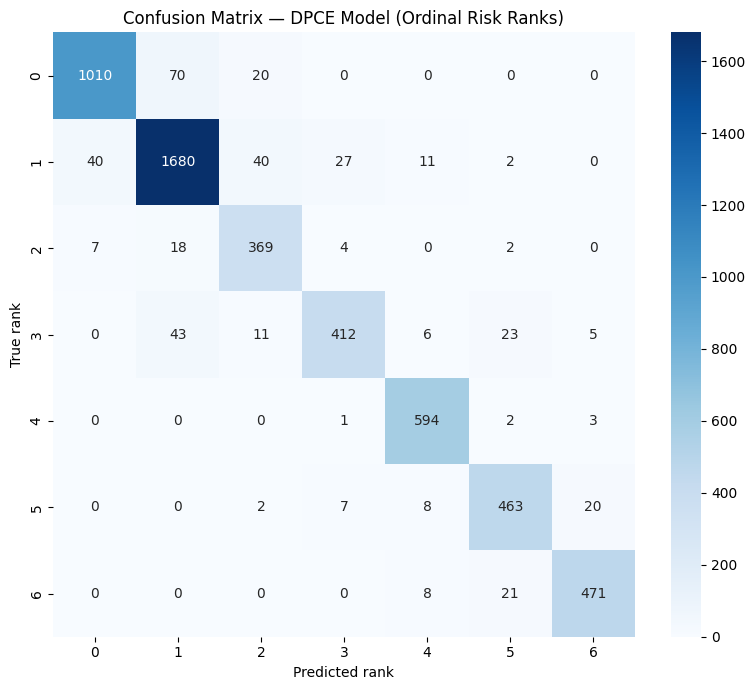

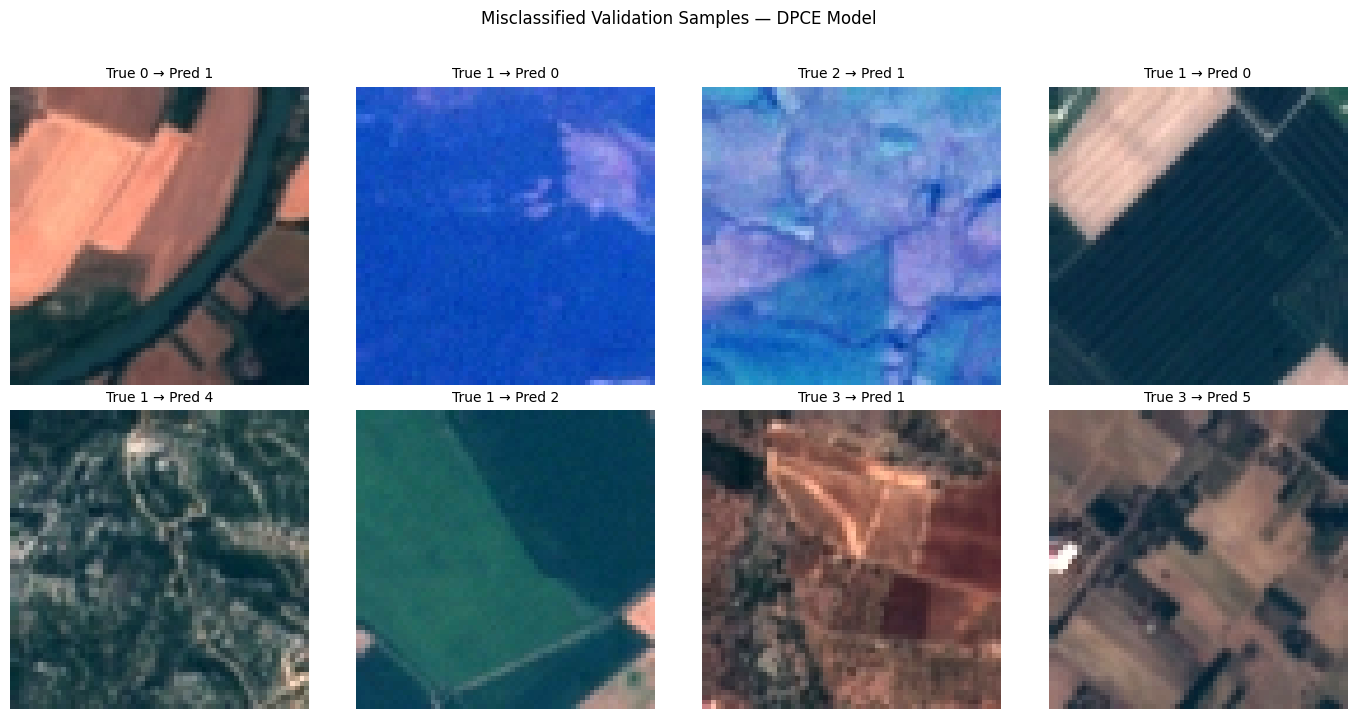

Copied /content/deepenmap_results/gradcam_samples.png -> /content/deepenmap_results/07_gradcam_heatmaps.png


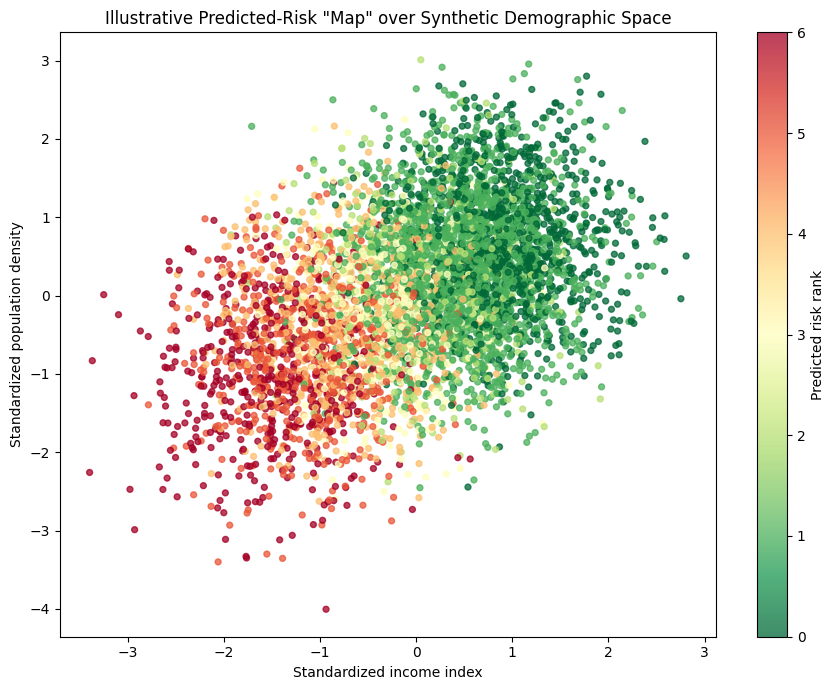


All 8 portfolio images are in: /content/deepenmap_results
Synced new images to Drive: /content/drive/MyDrive/DeepEnMap_Results


In [37]:

# Cell 12.3 — Extra portfolio images (01, 02, 03, 04, 05, 06, 08) + copy of 07
import shutil

portfolio_dir = CFG.output_dir  # same folder already holding exp2/exp4/gradcam PNGs

# ---- 01_class_distribution.png ----
plt.figure(figsize=(9, 5))
order = df["land_use_class"].value_counts().index
sns.countplot(data=df, y="land_use_class", order=order,
              hue="land_use_class", palette="viridis", legend=False)
plt.title("EuroSAT Class Distribution (Land-Use Categories)")
plt.xlabel("Number of images")
plt.ylabel("Land-use class")
plt.tight_layout()
plt.savefig(f"{portfolio_dir}/01_class_distribution.png", dpi=150)
plt.show()

# ---- 02_sample_grid.png ----
classes_sorted = sorted(RISK_MAPPING.items(), key=lambda kv: kv[1])
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (cls, rank) in zip(axes.flat, classes_sorted):
    sample_fp = df.loc[df["land_use_class"] == cls, "filepath"].iloc[0]
    img = load_and_preprocess_image(tf.constant(sample_fp), CFG.img_size).numpy()
    ax.imshow(img)
    ax.set_title(f"{cls}\n(risk {rank})", fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Patches per Land-Use Class, Ordered by Risk Rank", y=1.02)
plt.tight_layout()
plt.savefig(f"{portfolio_dir}/02_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 03_model_architecture.png ----
try:
    keras.utils.plot_model(
        model_dpce, to_file=f"{portfolio_dir}/03_model_architecture.png",
        show_shapes=True, show_layer_names=True, expand_nested=True, dpi=150
    )
    print("Saved 03_model_architecture.png")
except Exception as e:
    print("plot_model failed (pydot/graphviz missing?) —", e)
    print("Fix in Colab with: !apt-get -qq install graphviz && !pip -q install pydot")

# ---- 04_training_history.png ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_ce.history["loss"], label="CE — train")
axes[0].plot(history_ce.history["val_loss"], label="CE — val")
axes[0].plot(history_dpce.history["loss"], label="DPCE — train")
axes[0].plot(history_dpce.history["val_loss"], label="DPCE — val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_ce.history["accuracy"], label="CE — train")
axes[1].plot(history_ce.history["val_accuracy"], label="CE — val")
axes[1].plot(history_dpce.history["accuracy"], label="DPCE — train")
axes[1].plot(history_dpce.history["val_accuracy"], label="DPCE — val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{portfolio_dir}/04_training_history.png", dpi=150)
plt.show()

# ---- 05_confusion_matrix.png ----
plt.figure(figsize=(8, 7))
sns.heatmap(metrics_dpce["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=range(CFG.n_classes), yticklabels=range(CFG.n_classes))
plt.title("Confusion Matrix — DPCE Model (Ordinal Risk Ranks)")
plt.xlabel("Predicted rank")
plt.ylabel("True rank")
plt.tight_layout()
plt.savefig(f"{portfolio_dir}/05_confusion_matrix.png", dpi=150)
plt.show()

# ---- Rebuild a flat, unshuffled view of val images/demos (shared by 06 & 08) ----
val_imgs_all, val_demos_all = [], []
for (imgs, demos), _ in val_ds:
    val_imgs_all.append(imgs.numpy())
    val_demos_all.append(demos.numpy())
val_imgs_all = np.concatenate(val_imgs_all, axis=0)
val_demos_all = np.concatenate(val_demos_all, axis=0)

# ---- 06_misclassified_examples.png ----
mis_idx = np.where(metrics_dpce["y_true"] != metrics_dpce["y_pred"])[0]
show_n = min(8, len(mis_idx))
picked = np.random.default_rng(SEED_SET[0]).choice(mis_idx, size=show_n, replace=False) if show_n else np.array([], dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, idx in zip(axes.flat, picked):
    ax.imshow(val_imgs_all[idx])
    ax.set_title(f"True {metrics_dpce['y_true'][idx]} → Pred {metrics_dpce['y_pred'][idx]}", fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(picked):]:
    ax.axis("off")
plt.suptitle("Misclassified Validation Samples — DPCE Model", y=1.02)
plt.tight_layout()
plt.savefig(f"{portfolio_dir}/06_misclassified_examples.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- 07_gradcam_heatmaps.png (copy/rename from existing Grad-CAM figure) ----
src_gradcam = f"{portfolio_dir}/gradcam_samples.png"
dst_gradcam = f"{portfolio_dir}/07_gradcam_heatmaps.png"
if os.path.exists(src_gradcam):
    shutil.copy(src_gradcam, dst_gradcam)
    print(f"Copied {src_gradcam} -> {dst_gradcam}")
else:
    print("gradcam_samples.png not found — run Cell 11.2 first.")

# ---- 08_country_prediction_map.png ----
# NOTE: EuroSAT patches carry no real geocoordinates, and the demographic
# features from Cell 2.4 are synthetic (see Experimental Design § Demographic
# Data Source). This is an ILLUSTRATIVE "map" using two synthetic demographic
# axes as pseudo-coordinates, colored by the model's predicted risk rank —
# useful for the portfolio, but not a real geographic map.
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    val_demos_all[:, 0], val_demos_all[:, 3],   # income_index vs population_density
    c=metrics_dpce["y_pred"], cmap="RdYlGn_r", s=18, alpha=0.75
)
plt.colorbar(sc, label="Predicted risk rank")
plt.xlabel("Standardized income index")
plt.ylabel("Standardized population density")
plt.title('Illustrative Predicted-Risk "Map" over Synthetic Demographic Space')
plt.tight_layout()
plt.savefig(f"{portfolio_dir}/08_country_prediction_map.png", dpi=150)
plt.show()

print("\nAll 8 portfolio images are in:", portfolio_dir)

# ---- Re-sync to Drive (export_dir was created back in Cell 12.1) ----
if "export_dir" in globals():
    for fname in [
        "01_class_distribution.png", "02_sample_grid.png", "03_model_architecture.png",
        "04_training_history.png", "05_confusion_matrix.png", "06_misclassified_examples.png",
        "07_gradcam_heatmaps.png", "08_country_prediction_map.png",
    ]:
        fp = os.path.join(portfolio_dir, fname)
        if os.path.exists(fp):
            shutil.copy(fp, os.path.join(export_dir, fname))
    print("Synced new images to Drive:", export_dir)
else:
    print("export_dir not found — run Cell 12.1 first, or copy the files from", portfolio_dir, "manually.")
